## SWE - CppJIT - Thrust - SOLUTION

NumPy, JAX, PyOMP, and nanobind each rewrote the same step in a different way,
but nanobind required a separate build: edit the C++, run CMake, restart the
kernel, re-import. CppJIT removes that round-trip. We hand C++ or CUDA source to
CppJIT, and the declared C++ entities are usable from Python straight away with automatic bindings. This allows you to transparently pass Python objects (like NumPy arrays) to C++ interfaces and CppJIT generates the necessary CPython-level argument conversion and execution mechanisms for your C++ kernels. In
this notebook we write the step as a Thrust kernel and run the whole solve on the GPU.

**SOLUTION**

### Table of Contents

1. [Imports and activation](#sec1)
2. [The SWE solve on the GPU with Thrust](#sec2)
3. [Acceptance and timing](#sec3)
4. [Scaling: where the GPU wins](#sec4)
5. [Limitation: first-call compile latency](#sec5)

### <a id="sec1"></a>1. Imports and activation

`import cppjit` starts a live CUDA-enabled clang-repl interpreter, so the kernels below run on the GPU. We check for that image and stop early if it is missing.

---

**Quick Docs**

- `cppjit.cppdef(src)`: compile a block of C++ or CUDA source and link it into
  the session. The functions it declares become callable from Python automatically through proxies
- `cppjit.gbl.<name>(...)`: Proxy for declared C++ entities, in this case, functions. A contiguous `float64`
  array is passed straight through as a `double*`, with no copy.
- `cppjit.CUDA_ENABLED`: this is `True` when the interpreter was created with
  CUDA support.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import swe_core
import cppjit

assert cppjit.CUDA_ENABLED, \
    'This notebook needs the CUDA-enabled tutorial image.'

# Shared problem parameters.
N       = 16384
L       = 10.0
H0      = 1.0
AMP     = 0.1
SIG     = 0.5
CFL     = 0.4
G       = 9.81
N_STEPS = 1000
dx      = L / N
DT      = swe_core.fixed_dt(H0 + AMP, dx, cfl=CFL, g=G)

# Reference solution for the correctness gate (the NB 05 float64 solver).
def numpy_solve(n_cells, n_steps, cell_dx, step_dt):
    h, hu = swe_core.bump_ic(n_cells, L=L, h0=H0, amplitude=AMP, sigma=SIG)
    for _ in range(n_steps):
        swe_core.apply_bc_reflective(h, hu)
        h, hu = swe_core.step_numpy(h, hu, cell_dx, step_dt, g=G)
    return h, hu

h_ref, hu_ref = numpy_solve(N, N_STEPS, dx, DT)

### <a id="sec2"></a>2. The SWE solve on the GPU with Thrust

The same Rusanov step as notebook 04, now as a `thrust::for_each` over the
interior cells with the `thrust::device` policy. The fields live in CUDA managed
memory and the whole time loop runs on the device, boundary update and buffer
swap included, so we copy back and synchronise only once at the end. Keeping the
data resident is what makes the loop fast.

---

**Quick Docs**

- `thrust::for_each(thrust::device, first, last, f)`: run `f` on the GPU for each
  index in the range `[first, last)`.
- `[=] __device__ (long i) { ... }`: a CUDA lambda. It captures the field
  pointers by value and runs on the device.
- `thrust::counting_iterator<long>(k)`: a virtual sequence of indices starting at
  `k`, so we walk the cells without building an index array.
- `cudaMallocManaged`: allocate memory addressable from both the host and the
  device.

In [2]:
GPU_KERNEL = r"""
#include <cuda_runtime.h>
#include <thrust/execution_policy.h>
#include <thrust/for_each.h>
#include <thrust/iterator/counting_iterator.h>

__device__ inline void rusanov_face(double hL, double hR, double huL, double huR,
                                    double g, double& Fh, double& Fhu) {
  const double DRY = 1e-6;
  const double hL_s = hL > DRY ? hL : DRY, hR_s = hR > DRY ? hR : DRY;
  const double uL = huL / hL_s, uR = huR / hR_s;
  const double cL = sqrt(g * hL_s), cR = sqrt(g * hR_s);
  const double a = fmax(fabs(uL) + cL, fabs(uR) + cR);
  Fh  = 0.5 * (huL + huR) - 0.5 * a * (hR - hL);
  Fhu = 0.5 * (huL*uL + 0.5*g*hL*hL + huR*uR + 0.5*g*hR*hR) - 0.5 * a * (huR - huL);
}

void gpu_swe_solve(const double* h0, const double* hu0,
                   double* h_out, double* hu_out,
                   long Np2, double dx, double dt, double g, long n_steps) {
  const long N = Np2 - 2; const double inv = dt / dx;
  double *h, *hu, *hn, *hun;
  cudaMallocManaged(&h,  Np2*sizeof(double)); cudaMallocManaged(&hu,  Np2*sizeof(double));
  cudaMallocManaged(&hn, Np2*sizeof(double)); cudaMallocManaged(&hun, Np2*sizeof(double));
  for (long i = 0; i < Np2; ++i) { h[i] = h0[i]; hu[i] = hu0[i]; }
  for (long s = 0; s < n_steps; ++s) {
    double *H = h, *HU = hu, *HN = hn, *HUN = hun;
    // reflective boundary, on the device
    thrust::for_each(thrust::device, thrust::counting_iterator<long>(0),
        thrust::counting_iterator<long>(1), [=] __device__ (long) {
          H[0] = H[1]; H[Np2-1] = H[Np2-2]; HU[0] = -HU[1]; HU[Np2-1] = -HU[Np2-2];
          HN[0] = H[0]; HUN[0] = HU[0]; HN[Np2-1] = H[Np2-1]; HUN[Np2-1] = HU[Np2-1];
        });
    // interior Rusanov step, on the device
    thrust::for_each(thrust::device, thrust::counting_iterator<long>(1),
        thrust::counting_iterator<long>(N + 1), [=] __device__ (long i) {
          double Fw_h, Fw_hu, Fe_h, Fe_hu;
          rusanov_face(H[i-1], H[i],   HU[i-1], HU[i],   g, Fw_h, Fw_hu);
          rusanov_face(H[i],   H[i+1], HU[i],   HU[i+1], g, Fe_h, Fe_hu);
          HN[i]  = H[i]  - inv * (Fe_h  - Fw_h);
          HUN[i] = HU[i] - inv * (Fe_hu - Fw_hu);
        });
    double *t = h; h = hn; hn = t; t = hu; hu = hun; hun = t;
  }
  cudaDeviceSynchronize();
  for (long i = 0; i < Np2; ++i) { h_out[i] = h[i]; hu_out[i] = hu[i]; }
  cudaFree(h); cudaFree(hu); cudaFree(hn); cudaFree(hun);
}
"""

cppjit.cppdef(GPU_KERNEL)

def run_swe_gpu(n_cells=N, n_steps=N_STEPS):
    """Run the full SWE solve on the GPU and return the final (h, hu)."""
    cell_dx = L / n_cells
    step_dt = swe_core.fixed_dt(H0 + AMP, cell_dx, cfl=CFL, g=G)
    h, hu = swe_core.bump_ic(n_cells, L=L, h0=H0, amplitude=AMP, sigma=SIG)
    h = np.ascontiguousarray(h); hu = np.ascontiguousarray(hu)
    h_out = np.empty_like(h); hu_out = np.empty_like(hu)
    cppjit.gbl.gpu_swe_solve(h, hu, h_out, hu_out, h.shape[0],
                             cell_dx, step_dt, G, n_steps)
    return h_out, hu_out

### <a id="sec3"></a>3. Acceptance and timing

We run the full solve, check it against the float64 NumPy reference, and only
then report a time. Cold time is the first call, which pays the clang-repl
compile and the driver's first translation of the kernel to machine code. Warm
time is the median over repeated runs. The row is written to `timings.json` for
the synthesis notebook.

In [3]:
# Cold time is the first call, which compiles the kernel. Warm time is the median
# of repeated runs once it is compiled.
t0 = time.perf_counter()
h_gpu, _ = run_swe_gpu()
cold_s = time.perf_counter() - t0

warm = swe_core.timed_run(run_swe_gpu, warmup=2, repeats=5, label='05_cppjit_gpu')
diff = swe_core.max_diff(h_ref, h_gpu)
print(f'cold {cold_s*1e3:7.1f} ms   warm {warm["median_s"]*1e3:7.1f} ms   max_diff={diff:.2e}')
assert diff < 1e-12, f'FAIL: {diff:.2e} is not below 1e-12'
print('PASS: the GPU solve matches the float64 reference to 1e-12.')

swe_core.save_timing(
    warm, grid_str=f'N={N}', tool='cppjit_gpu_thrust', hardware='gpu',
    dtype='float64', steps=N_STEPS, cold_s=cold_s, max_diff_vs_numpy=diff)

cold   172.0 ms   warm    33.7 ms   max_diff=1.55e-15
PASS: the GPU solve matches the float64 reference to 1e-12.


### <a id="sec4"></a>4. Scaling: where the GPU wins

On a small grid a single step is too little work to fill the GPU, so it trails
NumPy. As the grid grows the GPU pulls far ahead. The sweep below plots both and
shows the crossover.

N=    1024   GPU      35 Mcell/s   NumPy     38 Mcell/s   speedup   0.9x
N=    4096   GPU     124 Mcell/s   NumPy     82 Mcell/s   speedup   1.5x
N=   16384   GPU     468 Mcell/s   NumPy    101 Mcell/s   speedup   4.7x


N=   65536   GPU    1031 Mcell/s   NumPy    111 Mcell/s   speedup   9.3x


N=  262144   GPU    1329 Mcell/s   NumPy     41 Mcell/s   speedup  32.6x


N= 1048576   GPU    1556 Mcell/s   NumPy     55 Mcell/s   speedup  28.1x


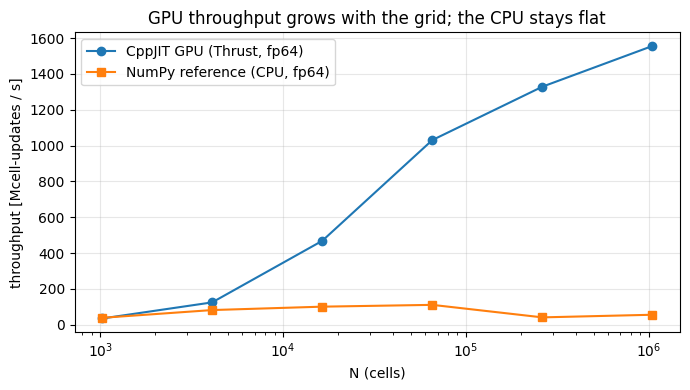

In [4]:
# Sweep the grid size and compare GPU throughput against the NumPy reference.
# We use a shorter run here (200 steps) so the sweep stays quick.
SWEEP_N = [1024, 4096, 16384, 65536, 262144, 1048576]
SWEEP_STEPS = 200

gpu_rate, npy_rate = [], []
for n_cells in SWEEP_N:
    cell_dx = L / n_cells
    step_dt = swe_core.fixed_dt(H0 + AMP, cell_dx, cfl=CFL, g=G)
    g = swe_core.timed_run(run_swe_gpu, n_cells, SWEEP_STEPS,
                           warmup=1, repeats=3, label=f'gpu_{n_cells}')
    n = swe_core.timed_run(numpy_solve, n_cells, SWEEP_STEPS, cell_dx, step_dt,
                           warmup=0, repeats=1, label=f'np_{n_cells}')
    gpu_rate.append(n_cells * SWEEP_STEPS / g["median_s"] / 1e6)
    npy_rate.append(n_cells * SWEEP_STEPS / n["median_s"] / 1e6)
    print(f'N={n_cells:>8}   GPU {gpu_rate[-1]:7.0f} Mcell/s   '
          f'NumPy {npy_rate[-1]:6.0f} Mcell/s   speedup {gpu_rate[-1]/npy_rate[-1]:5.1f}x')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(SWEEP_N, gpu_rate, "o-", label="CppJIT GPU (Thrust, fp64)")
ax.plot(SWEEP_N, npy_rate, "s-", label="NumPy reference (CPU, fp64)")
ax.set_xscale("log")
ax.set_xlabel("N (cells)")
ax.set_ylabel("throughput [Mcell-updates / s]")
ax.set_title("GPU throughput grows with the grid; the CPU stays flat")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### <a id="sec5"></a>5. Limitation: first-call compile latency

CppJIT gives us C++ and CUDA as a notebook language: edit a cell, run it, call it
from Python. The one cost is the first call, which compiles before it runs. That
is the few-hundred-millisecond cold-versus-warm gap in section 3.

**Recap.**

- `cppjit.cppdef` compiles C++ or CUDA in the running session, and `cppjit.gbl`
  calls it with NumPy arrays as pointers.
- The same Rusanov step runs on the GPU with the `thrust::device` policy and the
  data kept resident.
- The GPU trails NumPy on a small grid but crosses over and pulls far ahead as
  `N` grows.

Next: `09__swe__synthesis.ipynb` collects every row from `timings.json` and compares
the tools on runtime, throughput, and memory footprint.